## **Libraries**

In [45]:
import sys
sys.path.append('../src')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

import visualizations

---
## **Feature Engineering**
### **Data Loading**

- Load data after the EDA process

In [46]:
path = "../datasets/df_after_eda.csv"

df = pd.read_csv(path)
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation,Year,Month,Quarter,Weekday,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,0,2009,12,4,Tuesday,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,2009,12,4,Tuesday,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,2009,12,4,Tuesday,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,0,2009,12,4,Tuesday,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,0,2009,12,4,Tuesday,30.0


---
### **Customer-Level Features**

In this project, we shift from transaction-level data to a **customer-level perspective**, since our goal is to predict customer behavior (whether a customer is likely to purchase again).

To achieve this, we aggregate transactional data and construct meaningful features that describe each customer's behavior.


Now, each row in the dataset represents a transaction, but:
- A single customer can have multiple transactions
- Behavioral patterns emerge only when we **aggregate activity per customer**

Therefore, we build a dataset where:
- Each row = one customer
- Each column = a behavioral feature


**RFM Features**

- **Recency (R)**: How recently the customer made a purchase, engagement measure.  
- **Frequency (F)**: How often the customer purchases, loyalty measure.
- **Monetary (M)**: How much the customer spends.


`Nevertheless, we have to take into consideration that we could NOT use ALL THE DATA, otherwise we will have **data leakage** in the target variable, since it will be created from the existing features`

- The data will be splitted into:
    - First 70% to build all features, except the target.
    - Last 30%, to create the target labels as which customers from the first 80% appear again as buyers in this new 20%. Having this way an approximation of customers that are likely to buy again.

In [47]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Here we are going to use the first 70% of the data 
split_date = df["InvoiceDate"].quantile(0.7)

# Past data (features)
df_past = df[df["InvoiceDate"] <= split_date]

# Future data (target)
df_future = df[df["InvoiceDate"] > split_date]


#### **RFM Features**

Customer behavior is summarized using the RFM framework. These features capture how recently a customer purchased, how frequently they buy, and how much they spend, providing a strong baseline for modeling customer value and engagement.

In [48]:
# Rebuild using past data only
df_sales_past = df_past[df_past["Cancellation"] == 0]

snapshot_date = df_past["InvoiceDate"].max()

rfm = df_sales_past.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days, # Days that each customer have since last invoice
    "Invoice": "nunique",
    "TotalPrice": "sum",
})

rfm.columns = ["Recency", "Frequency", "Monetary"]


#### **Incorporating Cancellations**

Cancellation-related features are added to capture potentially risky or inconsistent customer behavior. These variables help identify customers with higher return rates or negative purchasing patterns.

In [49]:
df_cancel_past = df_past[df_past["Cancellation"] == 1]

cancel_features = df_cancel_past.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).abs()

cancel_features.columns = ["NumCancellations", "CancelValue"]

rfm = rfm.merge(cancel_features, how="left", on="Customer ID")
rfm = rfm.fillna(0)

rfm["CancelRate"] = rfm["NumCancellations"] / (rfm["Frequency"] + 1)
rfm["CancelValueRatio"] = rfm["CancelValue"] / (rfm["Monetary"] + 1)


#### **Additional Features**

Additional features are created to enrich customer profiles, including geographic information and behavioral metrics such as lifetime, average order value, and purchase intensity. These features provide more detailed insights into customer habits.

In [50]:
# Country (most frequent per customer)
customer_country = (
    df.groupby("Customer ID")["Country"]
    .agg(lambda x: x.mode()[0])
)
#rfm = rfm.merge(customer_country, on="Customer ID", how="left")


# Customer lifetime
customer_dates = df_sales_past.groupby("Customer ID").agg({
    "InvoiceDate": ["min", "max"]
})

customer_dates.columns = ["FirstPurchase", "LastPurchase"]

customer_dates["CustomerLifetime"] = (
    customer_dates["LastPurchase"] - customer_dates["FirstPurchase"]
).dt.days
rfm = rfm.merge(customer_dates["CustomerLifetime"], on="Customer ID", how="left")


# Average order value
rfm["AvgOrderValue"] = rfm["Monetary"] / (rfm["Frequency"] + 1)

# Average quantity
quantity_per_customer = df_sales_past.groupby("Customer ID")["Quantity"].sum()
rfm["AvgQuantity"] = quantity_per_customer / (rfm["Frequency"] + 1)

# Purchase frequency rate
rfm["PurchaseFrequencyRate"] = rfm["Frequency"] / (rfm["CustomerLifetime"] + 1)

In [51]:
rfm.head()

,Recency,Frequency,Monetary,NumCancellations,CancelValue,CancelRate,CancelValueRatio,CustomerLifetime,AvgOrderValue,AvgQuantity,PurchaseFrequencyRate
Customer ID,,,,,,,,,,,
12346,149,12,77556.46,5.0,77608.20,0.384615,1.000654,400,5965.881538,5714.230769,0.029925
12347,6,5,2817.48,0.0,0.00,0.000000,0.000000,220,469.580000,303.666667,0.022624
12348,72,4,1709.40,0.0,0.00,0.000000,0.000000,189,341.880000,499.400000,0.021053
12349,231,3,2671.14,1.0,24.15,0.250000,0.009038,181,667.785000,248.250000,0.016484
12350,133,1,334.40,0.0,0.00,0.000000,0.000000,0,167.200000,98.500000,1.000000


### **Target variable** 

The target is build by identifying thos customers that appear both in the present dataset and future dataset.

In [52]:
# Customers who bought in the future
future_customers = df_future[df_future["Cancellation"] == 0]["Customer ID"].unique()

# Build target
rfm["Target"] = rfm.index.isin(future_customers).astype(int)

rfm["Target"].value_counts()

Target
1    2564
0    2428
Name: count, dtype: int64

By doing the 70-30 partition, we end up with:
- 2564 customers that didn't order back
- 2428 customers that did order back

Almost perfectly balanced

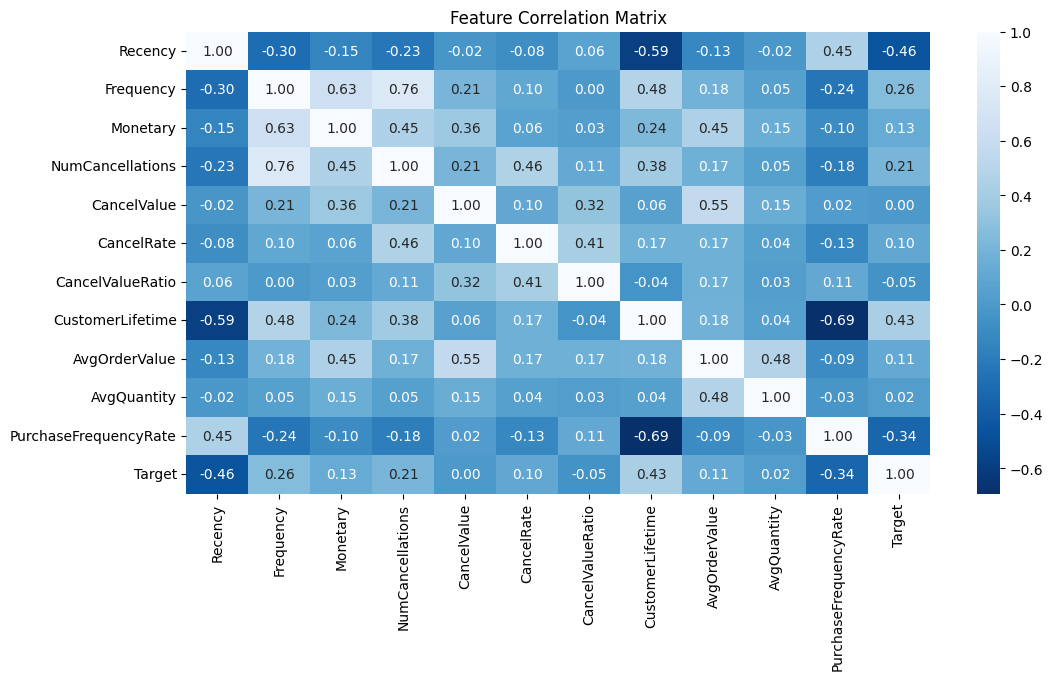

In [53]:
plt.figure(figsize=(12,6))
sns.heatmap(rfm.corr(), annot=True, fmt='.2f', cmap='Blues_r')
plt.title("Feature Correlation Matrix")
plt.show()

The correlation matrix highlights relationships between customer features and the target variable.

- **Recency** shows the strongest relationship with the target (-0.44), indicating that customers who purchased more recently are significantly more likely to buy again. This aligns with expectations and confirms Recency as a key predictive feature.

- **Frequency** has a moderate positive correlation with the target (0.27), suggesting that customers who purchase more often are more likely to return.

- **CustomerLifetime** also shows a positive correlation with the target (0.38), meaning long-term customers tend to be more loyal.

- **PurchaseFrequencyRate** has a negative correlation with the target (-0.29), likely due to its inverse relationship with CustomerLifetime, indicating some redundancy between these features.


- Strong correlations exist between:
  - **Frequency and NumCancellations (0.77)** → more active customers naturally have more cancellations
  - **Frequency and Monetary (0.64)** → frequent buyers spend more
  - **AvgOrderValue and CancelValue (0.55)** → higher-value orders relate to higher cancellation values

- **CustomerLifetime and Recency (-0.60)** show a strong negative relationship, as expected:
  - Customers active for longer tend to have more recent purchases


Some features are moderately to highly correlated:
- Frequency, Monetary, and NumCancellations
- CustomerLifetime and PurchaseFrequencyRate

While tree-based models can handle this, linear models (like Logistic Regression) may be affected.

In [54]:
rfm.to_csv("../datasets/features.csv", index=True)